NOTEBOOK DE CALCUL DE STATS DE LA DISTANCE PAR RAPPORT AUX MEMBRES DU RESEAU EGO 

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [ ]:
df = pd.read_csv(" ")
df_liens = pd.read_csv(" ")


In [5]:
df.head()

,uriagent,nb_collaborateurs,moy_vol_oiseau_m,moy_reseau_reel_m,ratio_moy,med_vol_oiseau_m,med_reseau_reel_m,ratio_med,min_vol_oiseau_m,min_reseau_reel_m,max_vol_oiseau_m,max_reseau_reel_m,std_vol_oiseau_m,std_reseau_reel_m
0,http://rdf.geohistoricaldata.org/id/museeCarna...,1,2872.2566,2635.62,0.92,0.026501,2393.69,90323.64,2872.256595,147.01,2872.256595,7611.86,NaN,1412.83
1,http://rdf.geohistoricaldata.org/id/museeCarna...,2,1745.6656,2964.16,1.70,0.021700,2701.61,124499.68,1264.438131,106.72,2226.893126,8522.24,0.01,1571.47
2,http://rdf.geohistoricaldata.org/id/museeCarna...,5,2769.2912,3777.53,1.36,0.024461,3819.69,156154.20,181.661856,132.23,4627.203126,8244.85,0.02,1789.09
3,http://rdf.geohistoricaldata.org/id/museeCarna...,1,3675.7268,4946.85,1.35,0.049882,5072.76,101694.69,3675.726807,183.08,3675.726807,9767.32,NaN,1819.19
4,http://rdf.geohistoricaldata.org/id/museeCarna...,1,5286.9027,5112.69,0.97,0.065691,5398.18,82175.72,5286.902659,159.78,5286.902659,8986.61,NaN,1806.58


In [ ]:
percentiles = [0.05, 0.25, 0.50, 0.75, 0.90, 0.95]
cols_stats = ['moy_vol_oiseau_m', 'moy_reseau_reel_m', 'ratio_moy']

stats = df[cols_stats].describe(percentiles=percentiles).T
cols_order = [
    'count',
    'mean',
    'std',
    'min',
    '5%',
    '25%',
    '50%',
    '75%',
    '90%',
    '95%',
    'max',
]

print('=== RESUME STATISTIQUE ET QUANTILES ===')
print(stats[cols_order].round(2))

=== RESUME STATISTIQUE ET QUANTILES ===
                   count     mean      std      min       5%      25%  \
moy_vol_oiseau_m   199.0  3602.16  1690.07   193.48   998.41  2313.10   
moy_reseau_reel_m  199.0  3729.22   944.33  2471.76  2559.51  2962.70   
ratio_moy          199.0     1.47     1.79     0.51     0.58     0.81   

                       50%      75%      90%      95%      max  
moy_vol_oiseau_m   3565.80  4791.99  5837.95  6666.66  8262.08  
moy_reseau_reel_m  3626.81  4235.93  5121.03  5528.67  6972.76  
ratio_moy             1.07     1.44     2.10     2.88    18.90  


/tmp/ipykernel_361362/3186336061.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axes[0].set_xticklabels(["Vol d'oiseau", 'Réseau 1888 (Dijkstra)'])


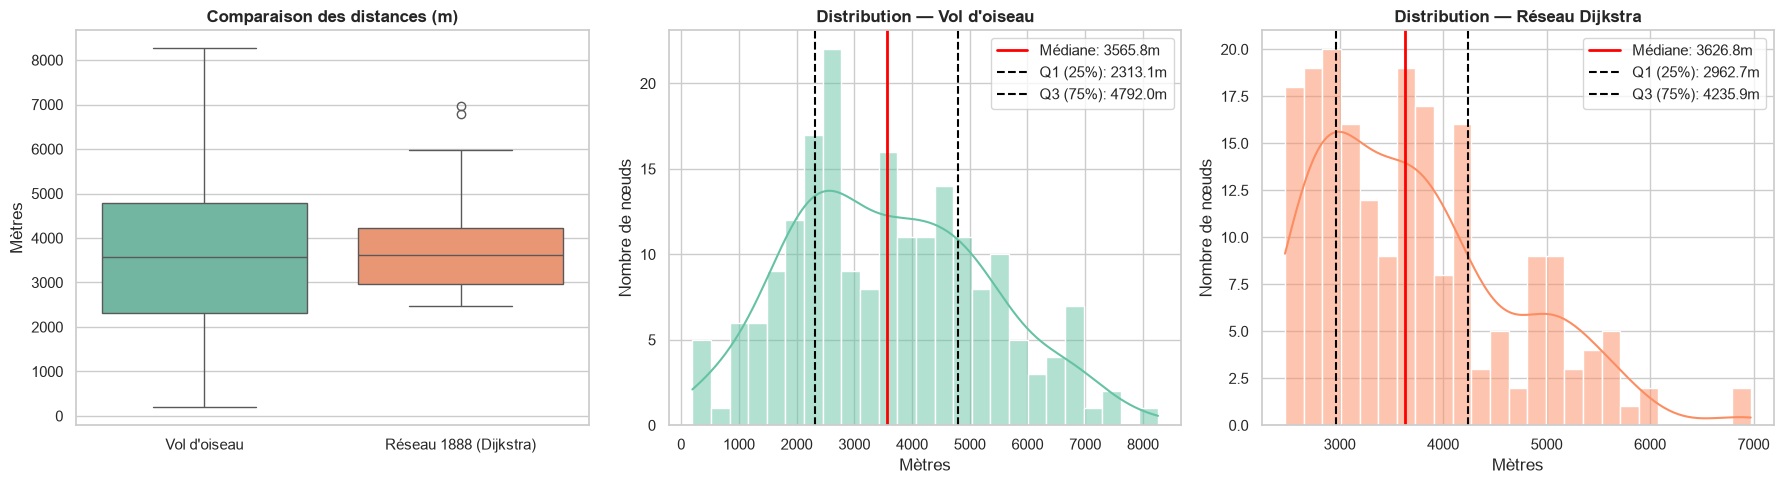

In [ ]:
sns.set_theme(style='whitegrid')
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.boxplot(
    data=df[['moy_vol_oiseau_m', 'moy_reseau_reel_m']],
    ax=axes[0],
    palette='Set2',
)
axes[0].set_title('Comparaison des distances (m)', fontweight='bold')
axes[0].set_xticklabels(["Vol d'oiseau", 'Réseau 1888 (Dijkstra)'])
axes[0].set_ylabel('Mètres')

data_vol = df['moy_vol_oiseau_m']
q1_v, med_v, q3_v = np.percentile(data_vol, [25, 50, 75])

sns.histplot(data_vol, kde=True, ax=axes[1], color='#66c2a5', bins=25)
axes[1].axvline(
    med_v, color='red', linestyle='-', linewidth=2, label=f'Médiane: {med_v:.1f}m'
)
axes[1].axvline(
    q1_v,
    color='black',
    linestyle='--',
    linewidth=1.5,
    label=f'Q1 (25%): {q1_v:.1f}m',
)
axes[1].axvline(
    q3_v,
    color='black',
    linestyle='--',
    linewidth=1.5,
    label=f'Q3 (75%): {q3_v:.1f}m',
)

axes[1].set_title("Distribution — Vol d'oiseau", fontweight='bold')
axes[1].set_xlabel('Mètres')
axes[1].set_ylabel('Nombre de nœuds')
axes[1].legend()

data_dij = df['moy_reseau_reel_m']
q1_d, med_d, q3_d = np.percentile(data_dij, [25, 50, 75])

sns.histplot(data_dij, kde=True, ax=axes[2], color='#fc8d62', bins=25)
axes[2].axvline(
    med_d, color='red', linestyle='-', linewidth=2, label=f'Médiane: {med_d:.1f}m'
)
axes[2].axvline(
    q1_d,
    color='black',
    linestyle='--',
    linewidth=1.5,
    label=f'Q1 (25%): {q1_d:.1f}m',
)
axes[2].axvline(
    q3_d,
    color='black',
    linestyle='--',
    linewidth=1.5,
    label=f'Q3 (75%): {q3_d:.1f}m',
)

axes[2].set_title('Distribution — Réseau Dijkstra', fontweight='bold')
axes[2].set_xlabel('Mètres')
axes[2].set_ylabel('Nombre de nœuds')
axes[2].legend()

plt.tight_layout()
plt.show()

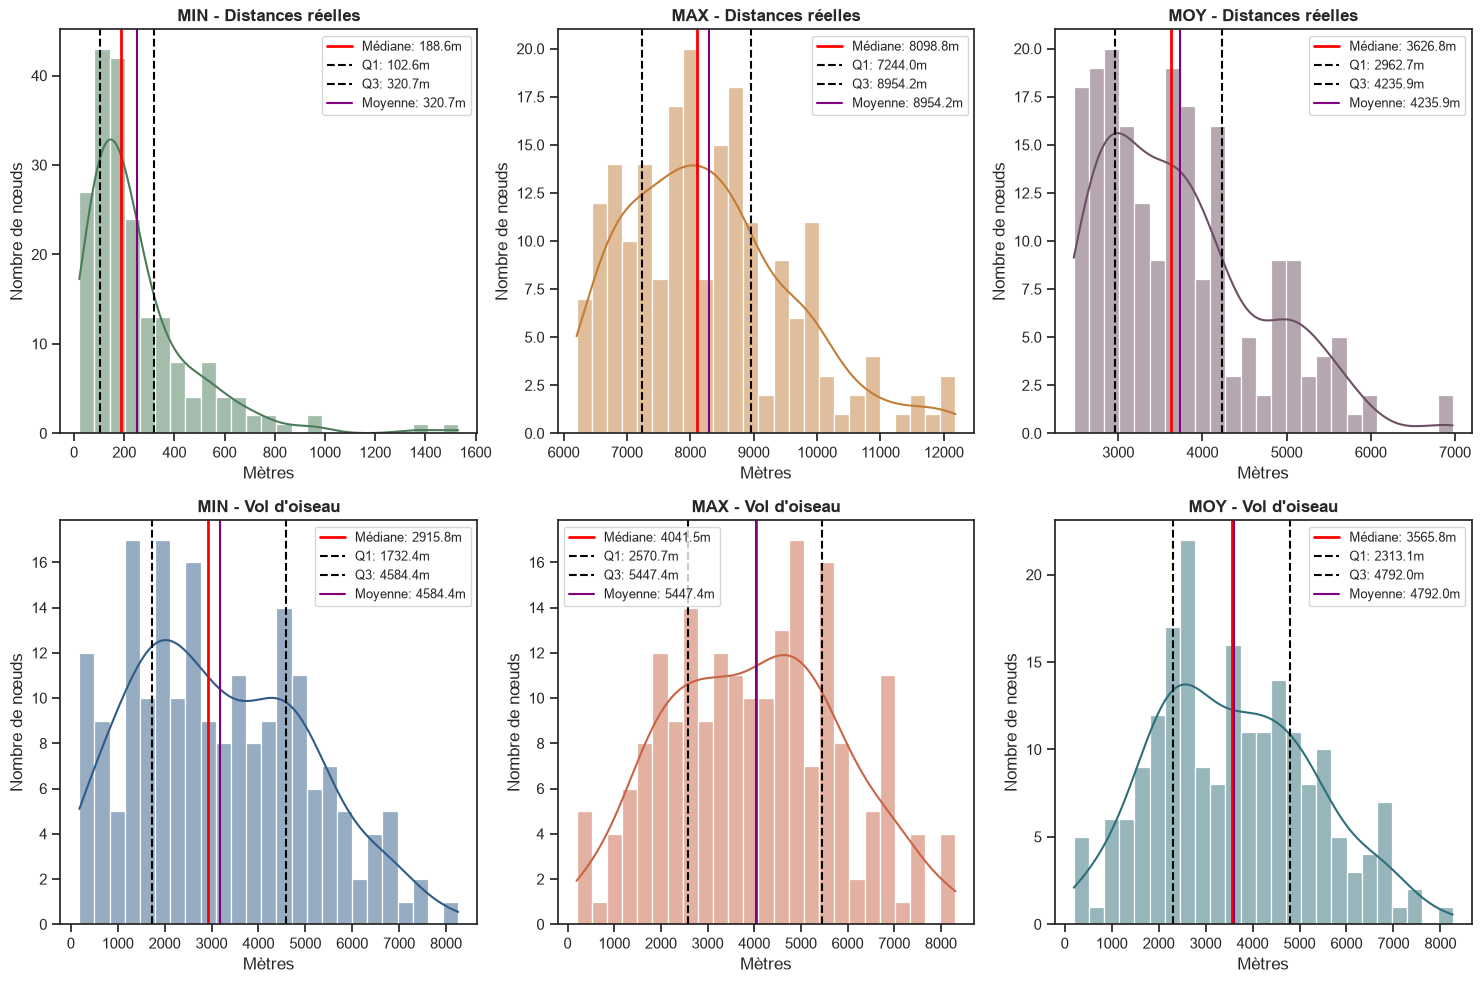

In [ ]:
sns.set_theme(style='ticks')
fig, axes = plt.subplots(2, 3, figsize=(15, 10))


def plot_distribution(data, ax, title, color):
  med = data.median()
  q1, q3 = np.percentile(data, [25, 75])
  moy = data.mean()


  sns.histplot(data, kde=True, ax=ax, color=color, bins=25)
  ax.axvline(
      med, color='red', linestyle='-', linewidth=2, label=f'Médiane: {med:.1f}m'
  )
  ax.axvline(
      q1, color='black', linestyle='--', linewidth=1.5, label=f'Q1: {q1:.1f}m'
  )
  ax.axvline(
      q3, color='black', linestyle='--', linewidth=1.5, label=f'Q3: {q3:.1f}m'
  )
  ax.axvline(
        moy, color='purple', linestyle='-', linewidth=1.5, label=f'Moyenne: {q3:.1f}m'
    )

  ax.set_title(title, fontweight='bold')
  ax.set_xlabel('Mètres')
  ax.set_ylabel('Nombre de nœuds')
  ax.legend(fontsize=9)

plot_distribution(
    df['min_vol_oiseau_m'],
    axes[1, 0],
    "MIN - Vol d'oiseau",
    '#2E5B88',
)
plot_distribution(
    df['min_reseau_reel_m'],
    axes[0, 0],
    'MIN - Distances réelles',
    '#4A7C59',
)

plot_distribution(
    df['max_vol_oiseau_m'],
    axes[1, 1],
    "MAX - Vol d'oiseau",
    '#C86446',
)

plot_distribution(
    df['max_reseau_reel_m'],
    axes[0, 1],
    'MAX - Distances réelles',
    '#C27D38',
)

plot_distribution(
    df['moy_vol_oiseau_m'],
    axes[1, 2],
    "MOY - Vol d'oiseau",
    '#2E6F7A',
)

plot_distribution(
    df['moy_reseau_reel_m'],
    axes[0, 2],
    'MOY - Distances réelles',
    '#6C4F63',
)

plt.tight_layout()
plt.show()

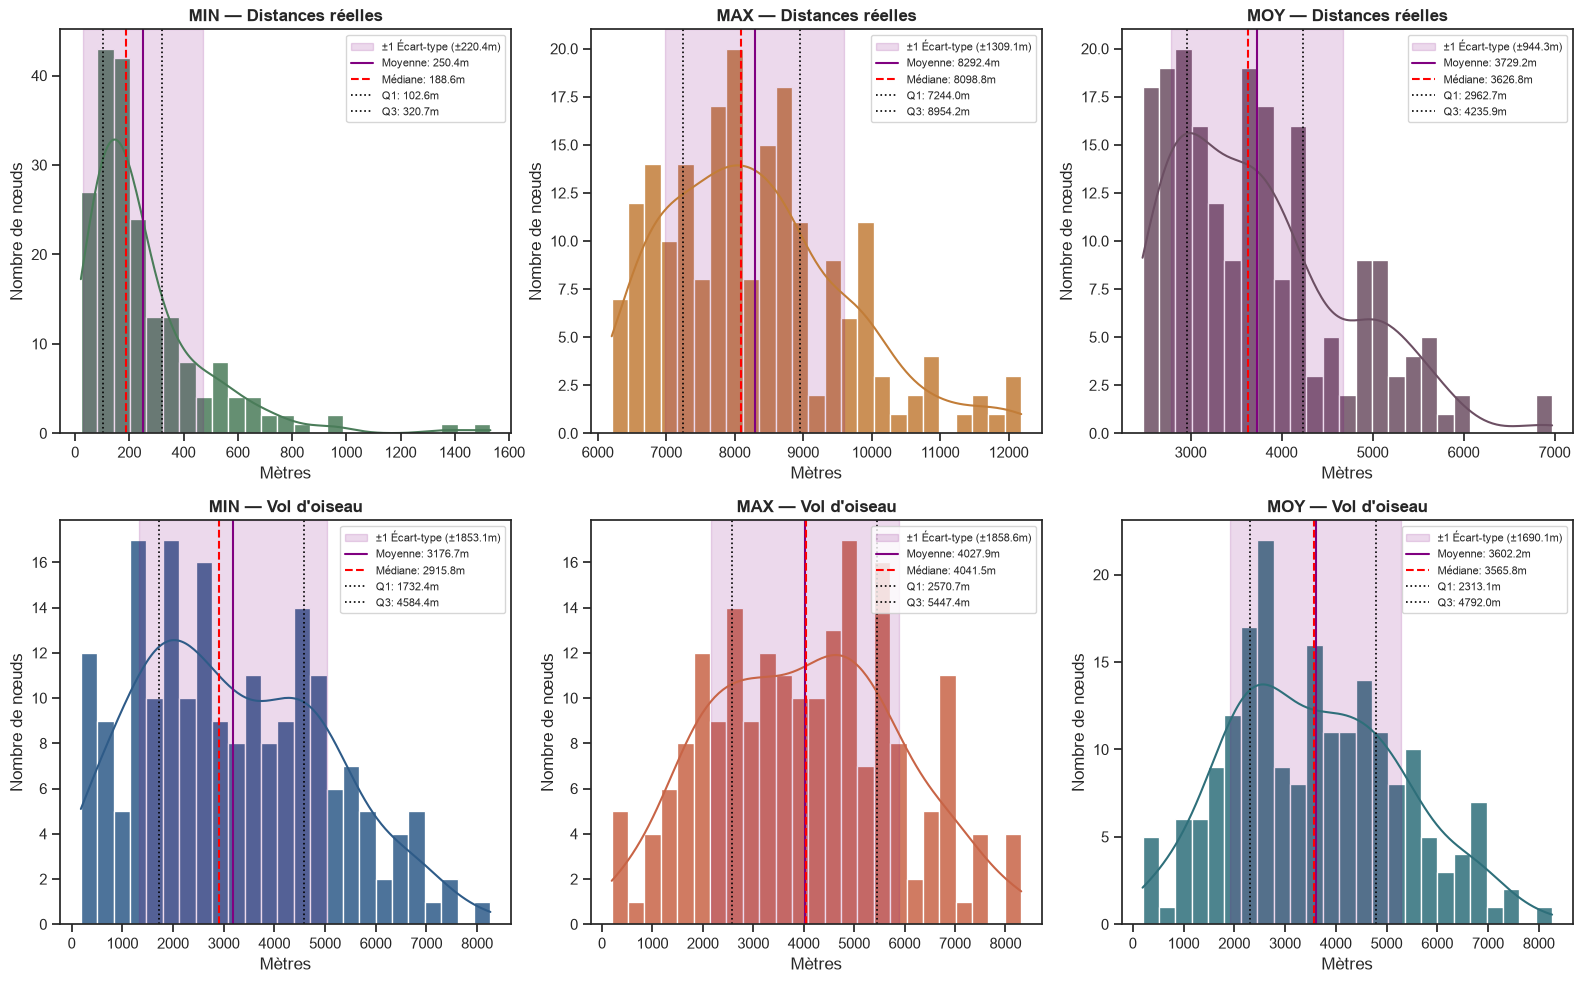

In [ ]:
sns.set_theme(style='ticks')
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

def plot_distribution(data, ax, title, color):
  med = data.median()
  q1, q3 = np.percentile(data, [25, 75])
  moy = data.mean()
  std = data.std()

  sns.histplot(data, kde=True, ax=ax, color=color, bins=25, alpha=0.85)

  ax.axvspan(
      moy - std,
      moy + std,
      color='purple',
      alpha=0.15,
      label=f'±1 Écart-type (±{std:.1f}m)',
  )

  ax.axvline(
      moy,
      color='purple',
      linestyle='-',
      linewidth=1.5,
      label=f'Moyenne: {moy:.1f}m',
  )
  ax.axvline(
      med, color='red', linestyle='--', linewidth=1.5, label=f'Médiane: {med:.1f}m'
  )
  ax.axvline(
      q1, color='black', linestyle=':', linewidth=1.2, label=f'Q1: {q1:.1f}m'
  )
  ax.axvline(
      q3, color='black', linestyle=':', linewidth=1.2, label=f'Q3: {q3:.1f}m'
  )

  ax.set_title(title, fontweight='bold')
  ax.set_xlabel('Mètres')
  ax.set_ylabel('Nombre de nœuds')
  ax.legend(fontsize=8, loc='upper right')

plot_distribution(
    df['min_reseau_reel_m'],
    axes[0, 0],
    'MIN — Distances réelles',
    '#4A7C59',
)

plot_distribution(
    df['max_reseau_reel_m'],
    axes[0, 1],
    'MAX — Distances réelles',
    '#C27D38',
)

plot_distribution(
    df['moy_reseau_reel_m'],
    axes[0, 2],
    'MOY — Distances réelles',
    '#6C4F63',
)

plot_distribution(
    df['min_vol_oiseau_m'],
    axes[1, 0],
    "MIN — Vol d'oiseau",
    '#2E5B88',
)

# E. Maxima Vol d'oiseau
plot_distribution(
    df['max_vol_oiseau_m'],
    axes[1, 1],
    "MAX — Vol d'oiseau",
    '#C86446',
)

plot_distribution(
    df['moy_vol_oiseau_m'],
    axes[1, 2],
    "MOY — Vol d'oiseau",
    '#2E6F7A',
)

plt.tight_layout()
plt.show()

/tmp/ipykernel_361362/1423887018.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axes[0].set_xticklabels(["Vol d'oiseau", 'Réseau 1888 (Dijkstra)'])


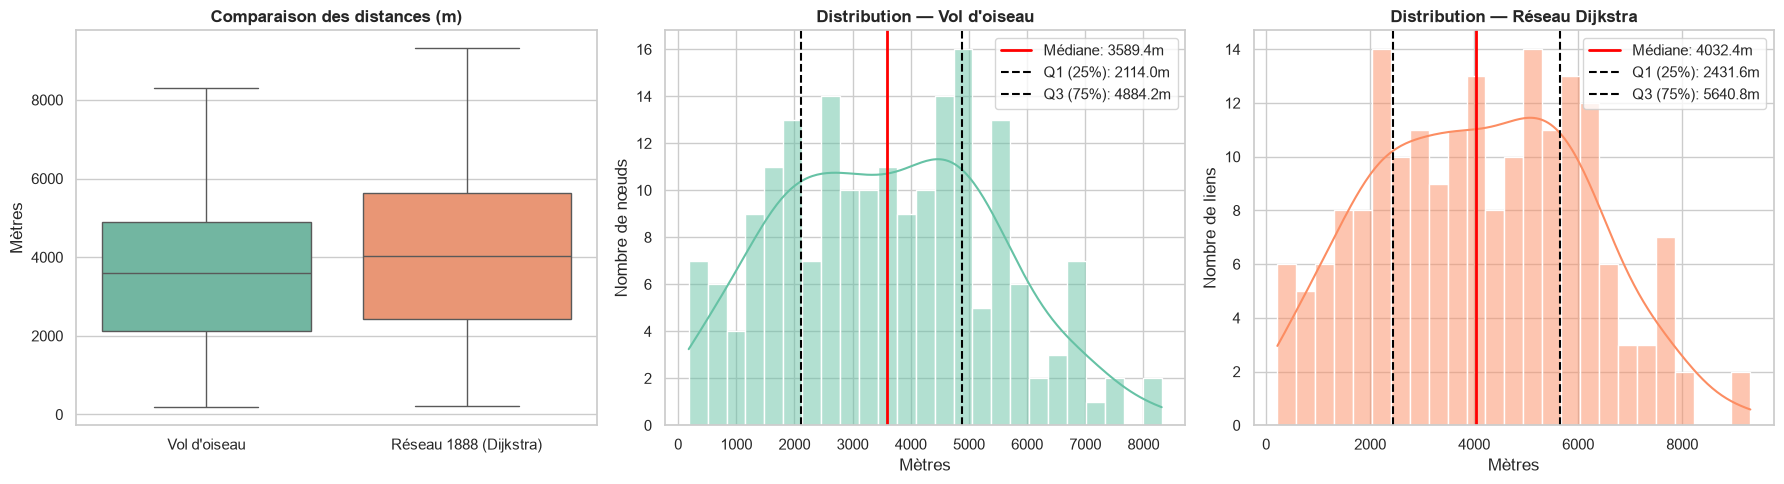

In [ ]:
sns.set_theme(style='whitegrid')
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.boxplot(
    data=df_liens[['distance_vol_oiseau', 'distance_reseau_reel']],
    ax=axes[0],
    palette='Set2',
)
axes[0].set_title('Comparaison des distances (m)', fontweight='bold')
axes[0].set_xticklabels(["Vol d'oiseau", 'Réseau 1888 (Dijkstra)'])
axes[0].set_ylabel('Mètres')

data_vol = df_liens['distance_vol_oiseau']
q1_v, med_v, q3_v = np.percentile(data_vol, [25, 50, 75])

sns.histplot(data_vol, kde=True, ax=axes[1], color='#66c2a5', bins=25)
axes[1].axvline(
    med_v, color='red', linestyle='-', linewidth=2, label=f'Médiane: {med_v:.1f}m'
)
axes[1].axvline(
    q1_v,
    color='black',
    linestyle='--',
    linewidth=1.5,
    label=f'Q1 (25%): {q1_v:.1f}m',
)
axes[1].axvline(
    q3_v,
    color='black',
    linestyle='--',
    linewidth=1.5,
    label=f'Q3 (75%): {q3_v:.1f}m',
)

axes[1].set_title("Distribution — Vol d'oiseau", fontweight='bold')
axes[1].set_xlabel('Mètres')
axes[1].set_ylabel('Nombre de nœuds')
axes[1].legend()

data_dij = df_liens['distance_reseau_reel']
q1_d, med_d, q3_d = np.percentile(data_dij, [25, 50, 75])

sns.histplot(data_dij, kde=True, ax=axes[2], color='#fc8d62', bins=25)
axes[2].axvline(
    med_d, color='red', linestyle='-', linewidth=2, label=f'Médiane: {med_d:.1f}m'
)
axes[2].axvline(
    q1_d,
    color='black',
    linestyle='--',
    linewidth=1.5,
    label=f'Q1 (25%): {q1_d:.1f}m',
)
axes[2].axvline(
    q3_d,
    color='black',
    linestyle='--',
    linewidth=1.5,
    label=f'Q3 (75%): {q3_d:.1f}m',
)

axes[2].set_title('Distribution — Réseau Dijkstra', fontweight='bold')
axes[2].set_xlabel('Mètres')
axes[2].set_ylabel('Nombre de liens')
axes[2].legend()

plt.tight_layout()
plt.show()

In [11]:
df_liens.head()

,lien_id,source_uri,target_uri,distance_vol_oiseau,distance_reseau_reel
0,12,http://rdf.geohistoricaldata.org/id/museeCarna...,http://rdf.geohistoricaldata.org/id/museeCarna...,683.305339,803.769330
1,13,http://rdf.geohistoricaldata.org/id/museeCarna...,http://rdf.geohistoricaldata.org/id/museeCarna...,5676.489877,6160.406486
2,14,http://rdf.geohistoricaldata.org/id/museeCarna...,http://rdf.geohistoricaldata.org/id/museeCarna...,3463.739135,4026.707482
3,15,http://rdf.geohistoricaldata.org/id/museeCarna...,http://rdf.geohistoricaldata.org/id/museeCarna...,3259.375952,3918.552833
4,16,http://rdf.geohistoricaldata.org/id/museeCarna...,http://rdf.geohistoricaldata.org/id/museeCarna...,3105.792451,3676.028498


/tmp/ipykernel_361362/1550072356.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axes[0].set_xticklabels(["Vol d'oiseau", 'Réseau 1888 (Dijkstra)'])


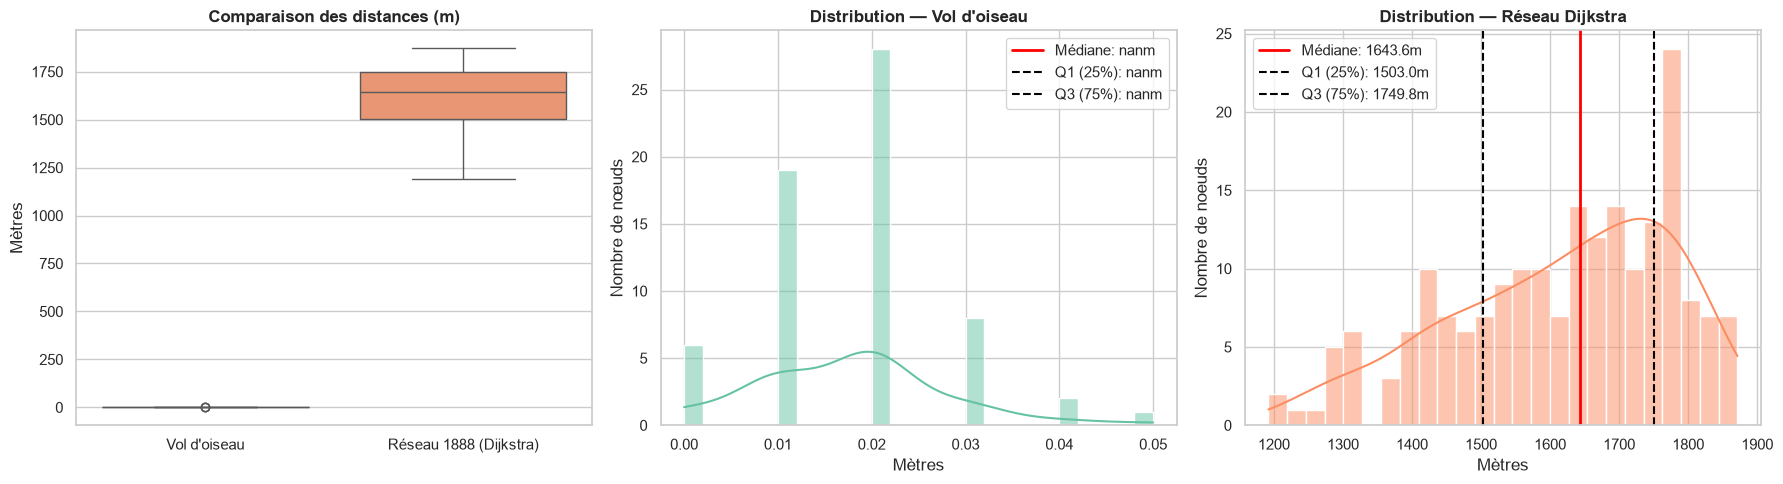

In [ ]:
sns.set_theme(style='whitegrid')
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.boxplot(
    data=df[['std_vol_oiseau_m', 'std_reseau_reel_m']],
    ax=axes[0],
    palette='Set2',
)
axes[0].set_title('Comparaison des distances (m)', fontweight='bold')
axes[0].set_xticklabels(["Vol d'oiseau", 'Réseau 1888 (Dijkstra)'])
axes[0].set_ylabel('Mètres')

data_vol = df['std_vol_oiseau_m']
q1_v, med_v, q3_v = np.percentile(data_vol, [25, 50, 75])

sns.histplot(data_vol, kde=True, ax=axes[1], color='#66c2a5', bins=25)
axes[1].axvline(
    med_v, color='red', linestyle='-', linewidth=2, label=f'Médiane: {med_v:.1f}m'
)
axes[1].axvline(
    q1_v,
    color='black',
    linestyle='--',
    linewidth=1.5,
    label=f'Q1 (25%): {q1_v:.1f}m',
)
axes[1].axvline(
    q3_v,
    color='black',
    linestyle='--',
    linewidth=1.5,
    label=f'Q3 (75%): {q3_v:.1f}m',
)

axes[1].set_title("Distribution — Vol d'oiseau", fontweight='bold')
axes[1].set_xlabel('Mètres')
axes[1].set_ylabel('Nombre de nœuds')
axes[1].legend()

data_dij = df['std_reseau_reel_m']
q1_d, med_d, q3_d = np.percentile(data_dij, [25, 50, 75])

sns.histplot(data_dij, kde=True, ax=axes[2], color='#fc8d62', bins=25)
axes[2].axvline(
    med_d, color='red', linestyle='-', linewidth=2, label=f'Médiane: {med_d:.1f}m'
)
axes[2].axvline(
    q1_d,
    color='black',
    linestyle='--', linewidth=1.5,
    label=f'Q1 (25%): {q1_d:.1f}m',
)
axes[2].axvline(
    q3_d,
    color='black',
    linestyle='--',
    linewidth=1.5,
    label=f'Q3 (75%): {q3_d:.1f}m',
)

axes[2].set_title('Distribution — Réseau Dijkstra', fontweight='bold')
axes[2].set_xlabel('Mètres')
axes[2].set_ylabel('Nombre de noeuds')
axes[2].legend()

plt.tight_layout()
plt.show()

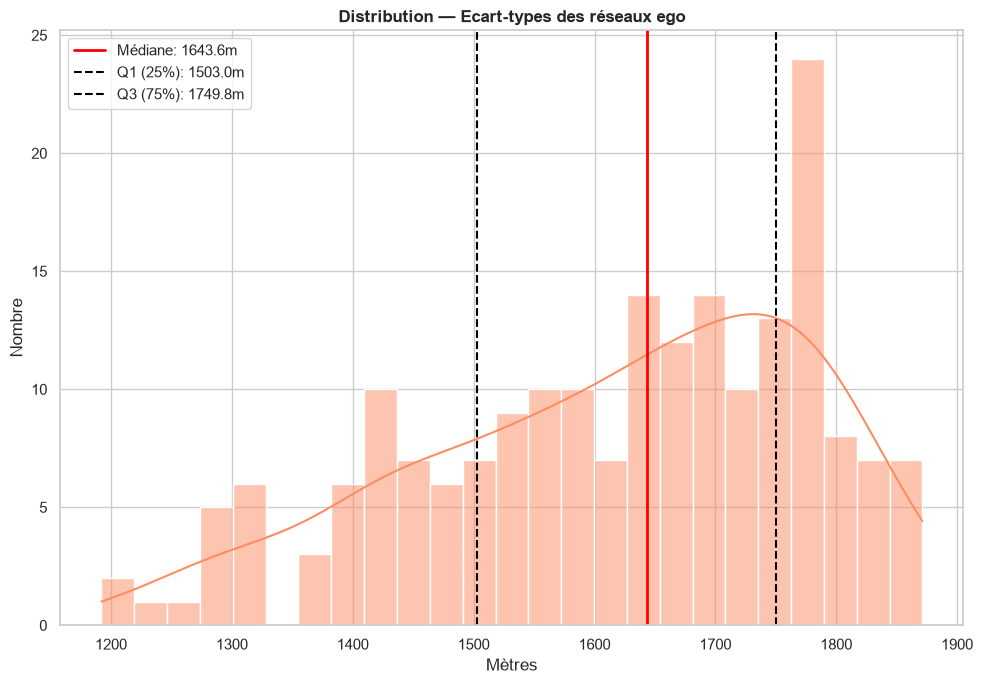

In [24]:
sns.set_theme(style='whitegrid')

data_dij = df['std_reseau_reel_m'].dropna()
q1_d, med_d, q3_d = np.percentile(data_dij, [25, 50, 75])

fig, ax = plt.subplots(figsize=(10, 7))

sns.histplot(data_dij, kde=True, ax=ax, color='#fc8d62', bins=25)
ax.axvline(
    med_d, color='red', linestyle='-', linewidth=2, label=f'Médiane: {med_d:.1f}m'
)
ax.axvline(
    q1_d,
    color='black',
    linestyle='--',
    linewidth=1.5,
    label=f'Q1 (25%): {q1_d:.1f}m',
)
ax.axvline(
    q3_d,
    color='black',
    linestyle='--',
    linewidth=1.5,
    label=f'Q3 (75%): {q3_d:.1f}m',
)

ax.set_title('Distribution — Ecart-types des réseaux ego', fontweight='bold')
ax.set_xlabel('Mètres')
ax.set_ylabel('Nombre')
ax.legend()

plt.tight_layout()
plt.show()